In [1]:
!pip install lifelines

  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=f32905db49b16f28308aea6069ed0010a484559240693f44d93a35f7aa747fb4
  Stored in directory: c:\users\leila\appdata\local\pip\cache\wheels\a8\03\64\8557323821d25118c3a2dc1646996f7a962a8970d4b7d22473
Successfully built autograd-gamma
  Attempting uninstall: pandas
    Found existing installation: pandas 1.4.2
    Uninstalling pandas-1.4.2:
      Successfully uninstalled pandas-1.4.2


c:\Users\leila\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\leila\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


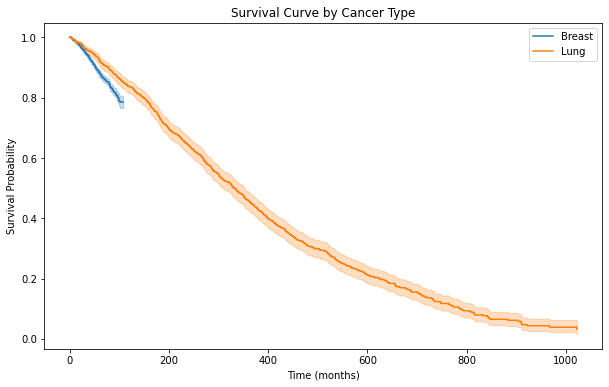

In [2]:
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

df = pd.read_csv("../01_Data/Processed/patients_master.csv")

df["survival_months"] = pd.to_numeric(df["survival_months"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")
df = df.dropna(subset=["cancer_type", "survival_months", "event"]).copy()

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for cancer in df["cancer_type"].dropna().unique():
    subset = df[df["cancer_type"] == cancer]
    
    kmf.fit(
        durations=subset["survival_months"],
        event_observed=subset["event"],
        label=cancer
    )
    
    kmf.plot_survival_function()

plt.title("Survival Curve by Cancer Type")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

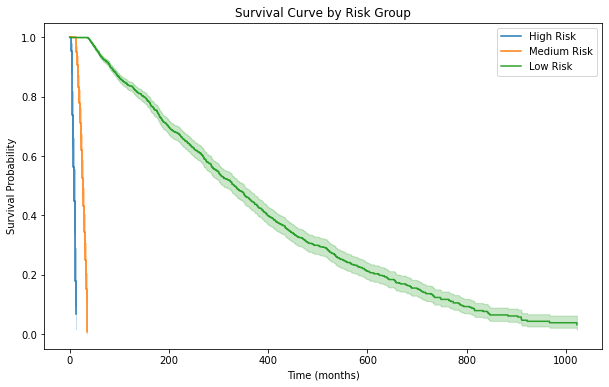

In [3]:
plt.figure(figsize=(10, 6))

for group in df["risk_group"].dropna().unique():
    subset = df[df["risk_group"] == group]
    
    kmf.fit(subset["survival_months"], subset["event"], label=group)
    kmf.plot_survival_function()

plt.title("Survival Curve by Risk Group")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()